In [68]:
import pandas as pd
from google.colab import files
uploaded = files.upload()

Saving Análise_dos_dados.ipynb to Análise_dos_dados (2).ipynb


In [69]:
df = pd.read_csv('testes.csv')

In [70]:
df_bfs = df[df['algorithm'] == 'BFS'].drop(columns=['algorithm']).reset_index(drop=True)
df_a_star = df[df['algorithm'] == 'A*'].drop(columns=['algorithm']).reset_index(drop=True)

In [71]:
display(df_bfs.head())

,vertices,probability,oriented,iteration,tot_dist,attempt_cnt
0,10,10,0,1,80,10
1,10,10,0,2,-1,2
2,10,10,0,5,-1,5
3,10,10,0,1,-1,1
4,10,10,0,1,-1,1


In [72]:
display(df_a_star.head())

,vertices,probability,oriented,iteration,tot_dist,attempt_cnt
0,10,10,0,4,80,37
1,10,10,0,2,-1,2
2,10,10,0,5,-1,5
3,10,10,0,1,-1,1
4,10,10,0,1,-1,1


In [73]:
import matplotlib.pyplot as plt

# Initialize counters
a_star_smaller = 0
bfs_smaller = 0
both_negative_one = 0
both_equal = 0

# Assuming df_bfs and df_a_star have the same length due to previous reset_index
# and that corresponding rows represent the same graph run.
for i in range(len(df_bfs)):
    tot_dist_bfs = df_bfs.loc[i, 'tot_dist']
    tot_dist_a_star = df_a_star.loc[i, 'tot_dist']

    if tot_dist_bfs == -1 and tot_dist_a_star == -1:
        both_negative_one += 1
    elif tot_dist_a_star < tot_dist_bfs:
        a_star_smaller += 1
    elif tot_dist_bfs < tot_dist_a_star:
        bfs_smaller += 1
    elif tot_dist_bfs == tot_dist_a_star:
        both_equal += 1

# Create a pandas Series for easy plotting
comparison_counts = pd.Series({
    'A*': a_star_smaller,
    'Busca em Largura': bfs_smaller,
    # 'Both -1': both_negative_one,
    'A* e Busca em Largura': both_equal
})

print("Comparação dos Resultados:")
display(comparison_counts)


Comparação dos Resultados:


,0
A*,3403
Busca em Largura,0
A* e Busca em Largura,2348


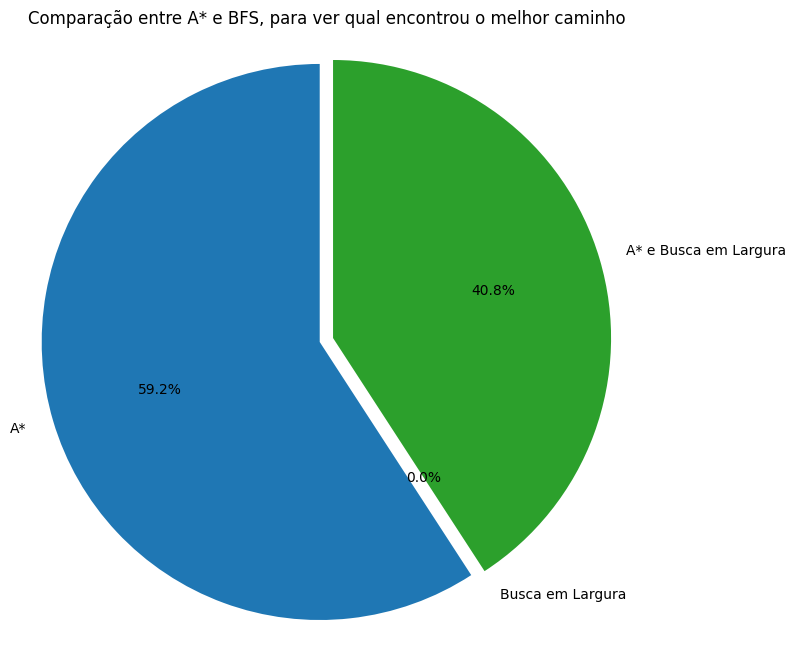

In [74]:
# Plotting the pie chart
plt.figure(figsize=(8, 8))
plt.pie(comparison_counts, labels=comparison_counts.index, autopct='%1.1f%%', startangle=90, explode=[0.05 if count == comparison_counts.max() else 0 for count in comparison_counts])
plt.title('Comparação entre A* e BFS, para ver qual encontrou o melhor caminho')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Comparison of Mean `attempt_cnt` and Mean `iteration`

In [75]:
print("Média de tentativas de inserções na fronteira (BFS):", df_bfs['attempt_cnt'].mean())
print("Média de tentativas de inserções na fronteira (A*):", df_a_star['attempt_cnt'].mean())

print("\nMédia de iterações (BFS):", df_bfs['iteration'].mean())
print("Média de iterações (A*):", df_a_star['iteration'].mean())

Média de tentativas de inserções na fronteira (BFS): 32161.029666666665
Média de tentativas de inserções na fronteira (A*): 3481.3955

Média de iterações (BFS): 100.75333333333333
Média de iterações (A*): 13.536166666666666


### Comparison of Iteration Differences

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the difference in iterations (A* iterations - BFS iterations)
# A negative value means A* used fewer iterations, a positive value means BFS used fewer.
iteration_difference = df_a_star['iteration'] - df_bfs['iteration']

# Filter for cases where A* used fewer iterations and take the absolute difference
a_star_less_iterations_abs_diff = iteration_difference[iteration_difference < 0].abs()

# Filter for cases where BFS used fewer iterations and take the absolute difference
bfs_less_iterations_abs_diff = iteration_difference[iteration_difference > 0].abs()

print(f"Quantidade de vezes que \'iteration\' de A* foi menor: {len(a_star_less_iterations_abs_diff)}")
print(f"Quantidade de vezes que \'iteration\' da Busca em Largura foi menor: {len(bfs_less_iterations_abs_diff)}")
print(f"Quantidade de vezes que foram iguais: {len(iteration_difference[iteration_difference == 0])}")

Quantidade de vezes que 'iteration' de A* foi menor: 2125
Quantidade de vezes que 'iteration' da Busca em Largura foi menor: 2429
Quantidade de vezes que foram iguais: 1446


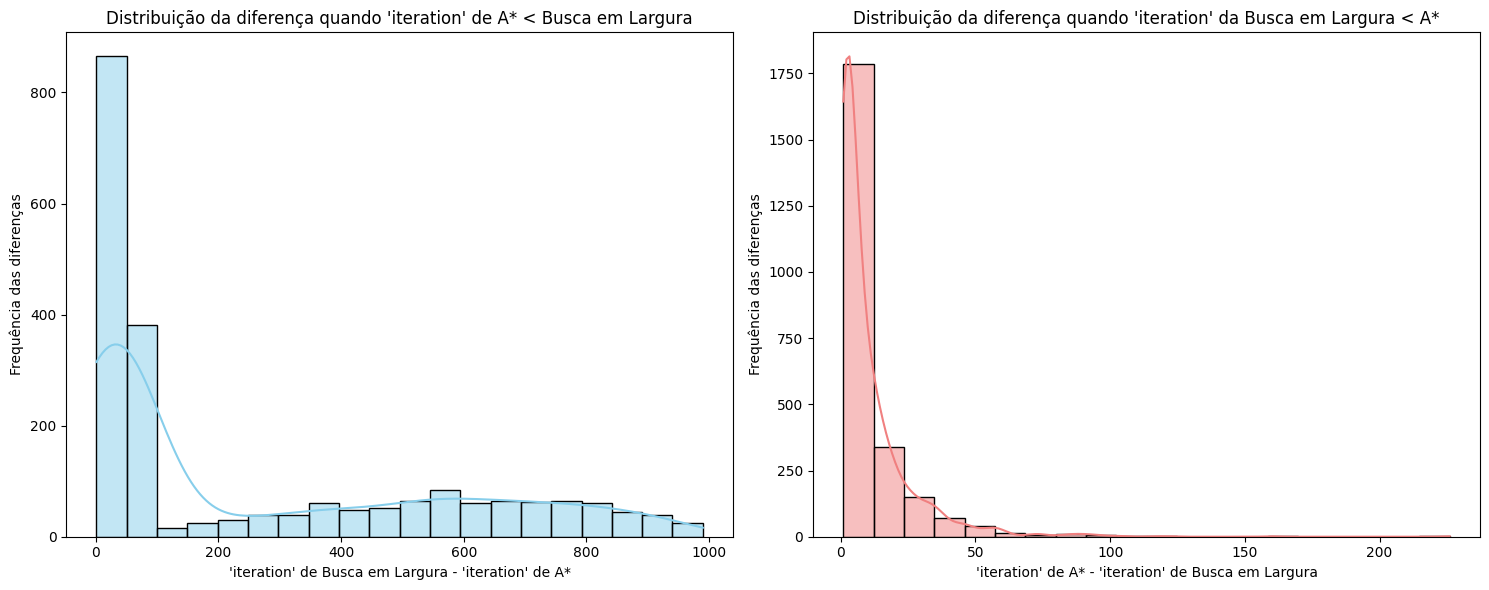

In [77]:
plt.figure(figsize=(15, 6))

# Plot distribution when A* uses less iterations (absolute difference)
plt.subplot(1, 2, 1)
sns.histplot(a_star_less_iterations_abs_diff, kde=True, color='skyblue', bins=20)
plt.title('Distribuição da diferença quando \'iteration\' de A* < Busca em Largura')
plt.xlabel('\'iteration\' de Busca em Largura - \'iteration\' de A*')
plt.ylabel('Frequência das diferenças')

# Plot distribution when BFS uses less iterations (absolute difference)
plt.subplot(1, 2, 2)
sns.histplot(bfs_less_iterations_abs_diff, kde=True, color='lightcoral', bins=20)
plt.title('Distribuição da diferença quando \'iteration\' da Busca em Largura < A*')
plt.xlabel('\'iteration\' de A* - \'iteration\' de Busca em Largura')
plt.ylabel('Frequência das diferenças')

plt.tight_layout()
plt.show()

### Comparison of `attempt_cnt` Differences

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the difference in attempt_cnt (A* attempt_cnt - BFS attempt_cnt)
# A negative value means A* used fewer attempt_cnt, a positive value means BFS used fewer.
attempt_cnt_difference = df_a_star['attempt_cnt'] - df_bfs['attempt_cnt']

# Filter for cases where A* used fewer attempt_cnt and take the absolute difference
a_star_less_attempt_cnt_abs_diff = attempt_cnt_difference[attempt_cnt_difference < 0].abs()

# Filter for cases where BFS used fewer attempt_cnt and take the absolute difference
bfs_less_attempt_cnt_abs_diff = attempt_cnt_difference[attempt_cnt_difference > 0].abs()

print(f"Quantidade de vezes que \'attempt_cnt\' de A* foi menor: {len(a_star_less_attempt_cnt_abs_diff)}")
print(f"Quantidade de vezes que \'attempt_cnt\' da Busca em Largura foi menor: {len(bfs_less_attempt_cnt_abs_diff)}")
print(f"Quantidade de vezes que foram iguais: {len(attempt_cnt_difference[attempt_cnt_difference == 0])}")

Quantidade de vezes que 'attempt_cnt' de A* foi menor: 2123
Quantidade de vezes que 'attempt_cnt' da Busca em Largura foi menor: 2426
Quantidade de vezes que foram iguais: 1451


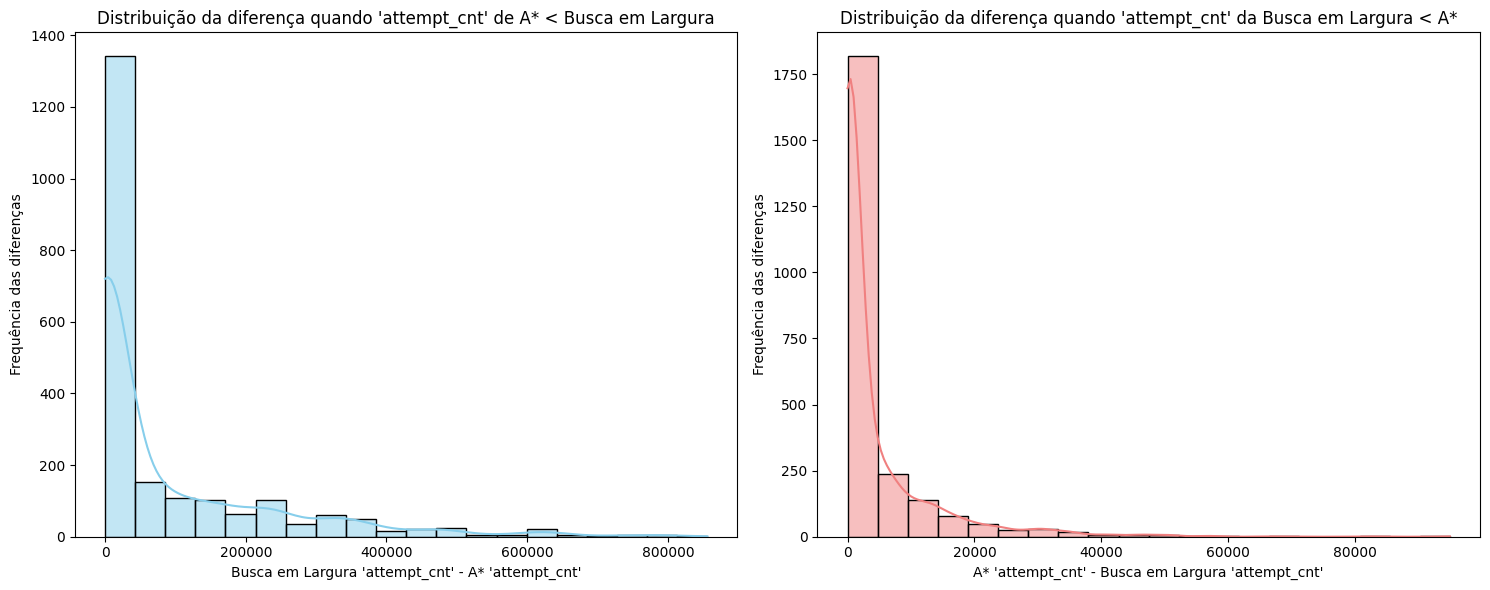

In [79]:
plt.figure(figsize=(15, 6))

# Plot distribution when A* uses less attempt_cnt (absolute difference)
plt.subplot(1, 2, 1)
sns.histplot(a_star_less_attempt_cnt_abs_diff, kde=True, color='skyblue', bins=20)
plt.title('Distribuição da diferença quando \'attempt_cnt\' de A* < Busca em Largura')
plt.xlabel('Busca em Largura \'attempt_cnt\' - A* \'attempt_cnt\'')
plt.ylabel('Frequência das diferenças')

# Plot distribution when BFS uses less attempt_cnt (absolute difference)
plt.subplot(1, 2, 2)
sns.histplot(bfs_less_attempt_cnt_abs_diff, kde=True, color='lightcoral', bins=20)
plt.title('Distribuição da diferença quando \'attempt_cnt\' da Busca em Largura < A*')
plt.xlabel('A* \'attempt_cnt\' - Busca em Largura \'attempt_cnt\'')
plt.ylabel('Frequência das diferenças')

plt.tight_layout()
plt.show()